In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
df = pd.read_excel("student_data.xlsx")
df.head()

,Student_ID,Name,Class,Maths,Science,English
0,101,Ananya,A,88,75,92
1,102,Priya,A,65,70,68
2,103,Ravi,B,45,52,49
3,104,Divya,B,95,91,89
4,105,Kavin,A,78,82,80


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Student_ID  30 non-null     int64 
 1   Name        30 non-null     object
 2   Class       30 non-null     object
 3   Maths       30 non-null     int64 
 4   Science     30 non-null     int64 
 5   English     30 non-null     int64 
dtypes: int64(4), object(2)
memory usage: 1.5+ KB


In [13]:
df.isnull().sum()

,0
Student_ID,0
Name,0
Class,0
Maths,0
Science,0
English,0


In [14]:
df.drop_duplicates(inplace=True)

print("Duplicates removed successfully")


Duplicates removed successfully


In [15]:
df["Total"] = (
    df["Maths"] +
    df["Science"] +
    df["English"]
)

df.head()

,Student_ID,Name,Class,Maths,Science,English,Total
0,101,Ananya,A,88,75,92,255
1,102,Priya,A,65,70,68,203
2,103,Ravi,B,45,52,49,146
3,104,Divya,B,95,91,89,275
4,105,Kavin,A,78,82,80,240


In [16]:
df["Average"] = df["Total"] / 3

df.head()

,Student_ID,Name,Class,Maths,Science,English,Total,Average
0,101,Ananya,A,88,75,92,255,85.000000
1,102,Priya,A,65,70,68,203,67.666667
2,103,Ravi,B,45,52,49,146,48.666667
3,104,Divya,B,95,91,89,275,91.666667
4,105,Kavin,A,78,82,80,240,80.000000


In [17]:
df.to_excel("student_progress.xlsx", index=False)

In [18]:
def grade(avg):
    if avg >= 90:
        return "A"
    elif avg >= 75:
        return "B"
    elif avg >= 60:
        return "C"
    elif avg >= 40:
        return "D"
    else:
        return "F"

df["Grade"] = df["Average"].apply(grade)

df.head()

,Student_ID,Name,Class,Maths,Science,English,Total,Average,Grade
0,101,Ananya,A,88,75,92,255,85.000000,B
1,102,Priya,A,65,70,68,203,67.666667,C
2,103,Ravi,B,45,52,49,146,48.666667,D
3,104,Divya,B,95,91,89,275,91.666667,A
4,105,Kavin,A,78,82,80,240,80.000000,B


In [19]:
df["Status"] = np.where(
    df["Average"] >= 40,
    "Pass",
    "Fail"
)

df.head()

,Student_ID,Name,Class,Maths,Science,English,Total,Average,Grade,Status
0,101,Ananya,A,88,75,92,255,85.000000,B,Pass
1,102,Priya,A,65,70,68,203,67.666667,C,Pass
2,103,Ravi,B,45,52,49,146,48.666667,D,Pass
3,104,Divya,B,95,91,89,275,91.666667,A,Pass
4,105,Kavin,A,78,82,80,240,80.000000,B,Pass


In [20]:
df["Rank"] = df["Average"].rank(
    ascending=False,
    method="min"
)

df = df.sort_values(
    by="Rank"
)

df.head(10)

,Student_ID,Name,Class,Maths,Science,English,Total,Average,Grade,Status,Rank
16,117,Rohit,A,97,94,96,287,95.666667,A,Pass,1.0
9,110,Nisha,B,92,95,93,280,93.333333,A,Pass,2.0
27,128,Shalini,B,93,90,92,275,91.666667,A,Pass,3.0
3,104,Divya,B,95,91,89,275,91.666667,A,Pass,3.0
19,120,Keerthana,B,91,89,94,274,91.333333,A,Pass,5.0
13,114,Lakshmi,B,89,86,90,265,88.333333,B,Pass,6.0
6,107,Surya,A,85,88,90,263,87.666667,B,Pass,7.0
23,124,Gayathri,B,87,84,88,259,86.333333,B,Pass,8.0
0,101,Ananya,A,88,75,92,255,85.000000,B,Pass,9.0
18,119,Manoj,A,83,85,82,250,83.333333,B,Pass,10.0


In [21]:
topper = df.iloc[0]

print("Topper Details")
print(topper)

Topper Details
Student_ID          117
Name              Rohit
Class                 A
Maths                97
Science              94
English              96
Total               287
Average       95.666667
Grade                 A
Status             Pass
Rank                1.0
Name: 16, dtype: object


In [22]:
top5 = df.head(5)

print(top5)

    Student_ID       Name Class  Maths  Science  English  Total    Average  \
16         117      Rohit     A     97       94       96    287  95.666667   
9          110      Nisha     B     92       95       93    280  93.333333   
27         128    Shalini     B     93       90       92    275  91.666667   
3          104      Divya     B     95       91       89    275  91.666667   
19         120  Keerthana     B     91       89       94    274  91.333333   

   Grade Status  Rank  
16     A   Pass   1.0  
9      A   Pass   2.0  
27     A   Pass   3.0  
3      A   Pass   3.0  
19     A   Pass   5.0  


In [23]:
pass_percentage = (
    (df["Status"] == "Pass").sum()
    / len(df)
) * 100

print(
    "Pass Percentage:",
    round(pass_percentage, 2),
    "%"
)

Pass Percentage: 96.67 %


In [24]:
subject_avg = df[
    ["Maths", "Science", "English"]
].mean()

print(subject_avg)

Maths      73.466667
Science    73.800000
English    74.833333
dtype: float64


Step 1 Chart avg mark

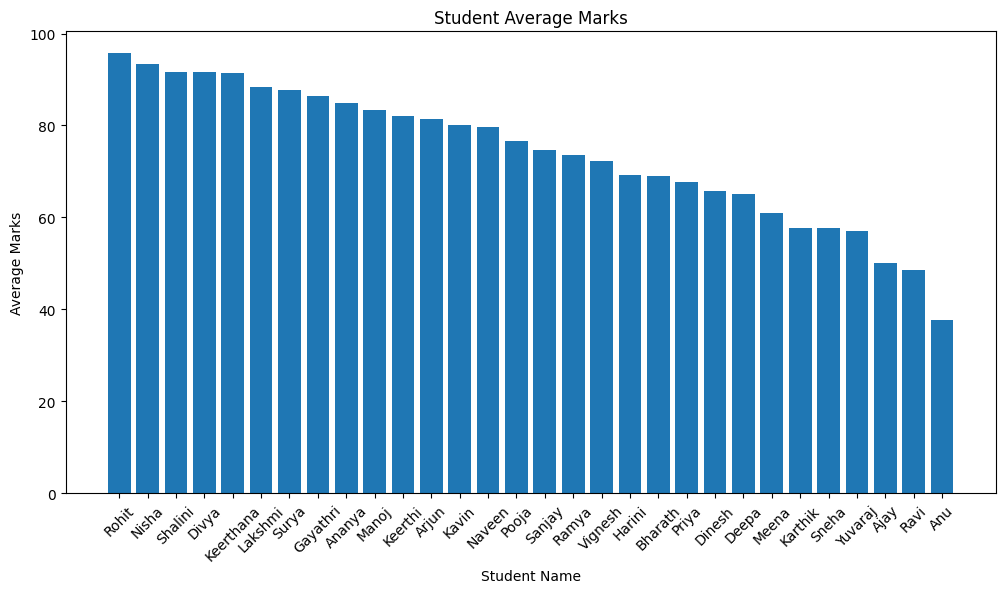

In [25]:
plt.figure(figsize=(12,6))

plt.bar(df["Name"], df["Average"])

plt.title("Student Average Marks")
plt.xlabel("Student Name")
plt.ylabel("Average Marks")

plt.xticks(rotation=45)

plt.show()

grade distrubution

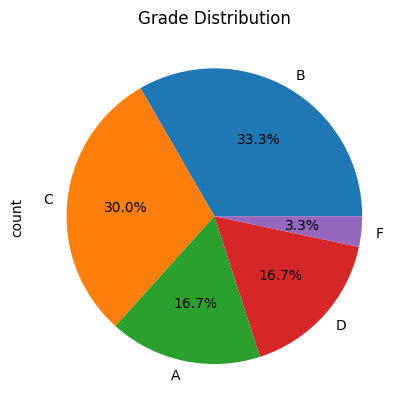

In [26]:
df["Grade"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Grade Distribution")

plt.show()

sub wise avg mark

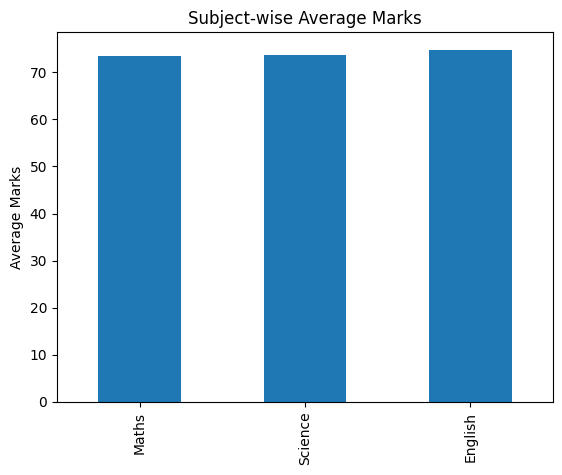

In [27]:
subject_avg.plot(
    kind="bar"
)

plt.title("Subject-wise Average Marks")
plt.ylabel("Average Marks")

plt.show()

export final report

In [28]:
df.to_excel(
    "Student_Performance_Report.xlsx",
    index=False
)

print("Report exported successfully")

Report exported successfully
